# Student Performance Prediction using Machine Learning

## Module 4 – Machine Learning Basics

This project uses Python and Scikit-learn to build a machine learning model
that predicts student performance based on relevant academic and study-related features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Student Performance dataset

df = pd.read_csv("student-mat.csv", sep=";")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 395
Columns: 33


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [7]:
# Check for duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
# Check missing values

missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

Total missing values: 0


In [9]:
# Check final grade distribution

print("Final Grade Statistics:")
print(df["G3"].describe())

Final Grade Statistics:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


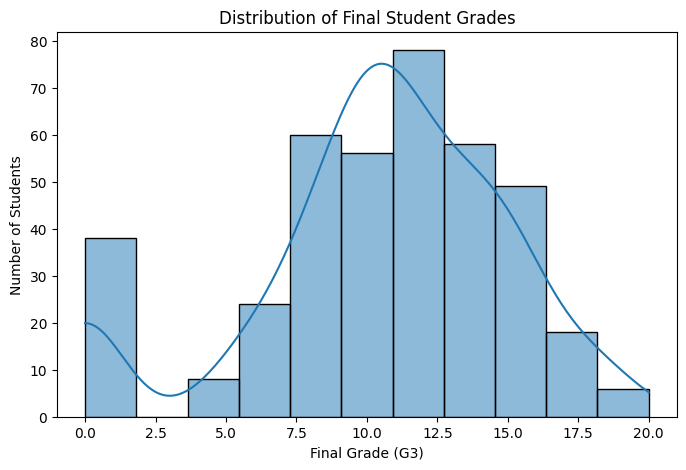

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df["G3"], bins=11, kde=True)

plt.title("Distribution of Final Student Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

In [11]:
features = ["studytime", "failures", "absences", "G1", "G2", "G3"]

df[features].head()

,studytime,failures,absences,G1,G2,G3
0,2,0,6,5,6,6
1,2,0,4,5,5,6
2,2,3,10,7,8,10
3,3,0,2,15,14,15
4,2,0,4,6,10,10


In [12]:
# Select features for prediction

features = ["studytime", "failures", "absences", "G1", "G2"]

X = df[features]
y = df["G3"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   studytime  failures  absences  G1  G2
0          2         0         6   5   6
1          2         0         4   5   5
2          2         3        10   7   8
3          3         0         2  15  14
4          2         0         4   6  10

Target (y):
0     6
1     6
2    10
3    15
4    10
Name: G3, dtype: int64


In [13]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 5)
y shape: (395,)


In [14]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 5)
Testing data: (79, 5)


In [15]:
# Create the Linear Regression model

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [16]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred[:10])

Predicted values:
[ 6.01113762 12.20306263  3.42583945  8.52243043  7.87300271 12.70478596
 18.6925959   7.10011213  7.22885591 12.6388124 ]


In [17]:
# Compare actual and predicted grades

comparison = pd.DataFrame({
    "Actual Grade": y_test.values,
    "Predicted Grade": y_pred
})

comparison.head(10)

,Actual Grade,Predicted Grade
0,10,6.011138
1,12,12.203063
2,5,3.425839
3,10,8.522430
4,9,7.873003
5,13,12.704786
6,18,18.692596
7,6,7.100112
8,0,7.228856
9,14,12.638812


In [18]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-------------------------")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

Model Evaluation
-------------------------
MAE  : 1.34
MSE  : 4.47
RMSE : 2.11
R²   : 0.78


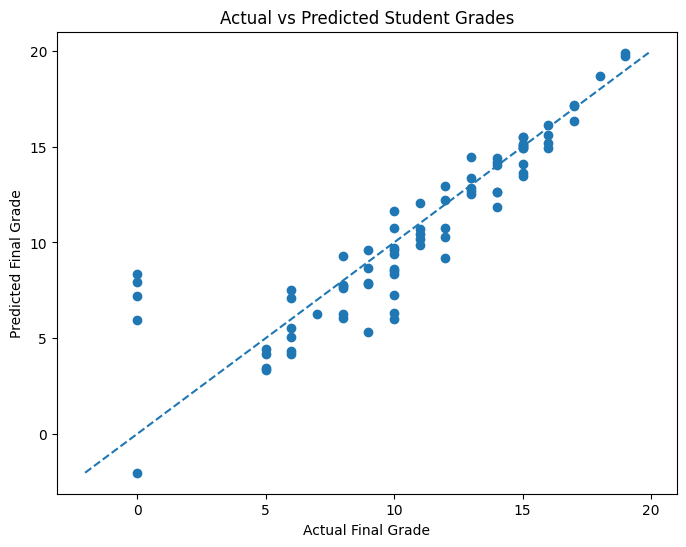

In [19]:
# Actual vs Predicted Grades

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Student Grades")

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

In [20]:
# Analyze feature influence

coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
4,G2,0.979615
3,G1,0.144463
2,absences,0.039245
0,studytime,-0.071231
1,failures,-0.455813


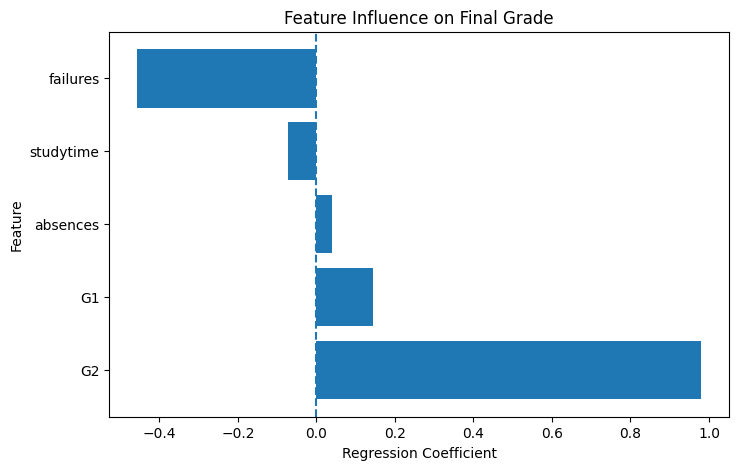

In [21]:
plt.figure(figsize=(8, 5))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Influence on Final Grade")
plt.axvline(0, linestyle="--")

plt.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
# Create and train Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [24]:
# Random Forest predictions

rf_pred = rf_model.predict(X_test)

In [25]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Evaluation")
print("-------------------------")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.2f}")

Random Forest Evaluation
-------------------------
MAE  : 1.05
RMSE : 1.62
R²   : 0.87


In [26]:
# Compare model performance

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R² Score": [r2, rf_r2]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.339416,2.113410,0.782175
1,Random Forest,1.052518,1.616757,0.872524


In [27]:
# Find the best model based on evaluation metrics

best_model = results.loc[results["R² Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Random Forest
MAE              1.052518
RMSE             1.616757
R² Score         0.872524
Name: 1, dtype: object


In [28]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,G2,0.813853
2,absences,0.119140
3,G1,0.031818
0,studytime,0.020381
1,failures,0.014807


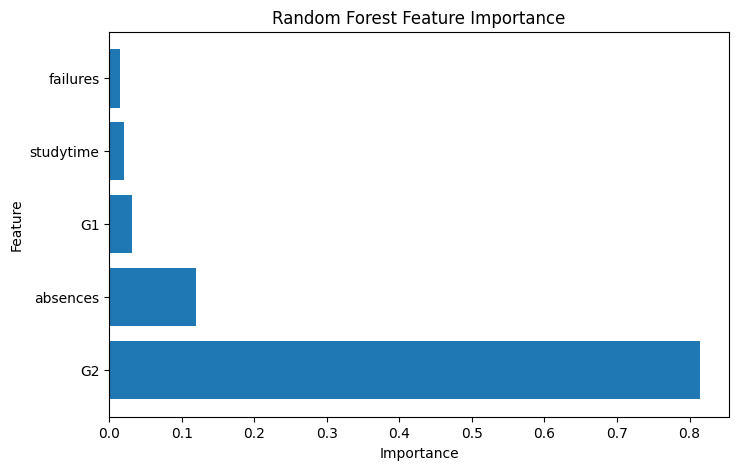

In [29]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [30]:
# Example student prediction

student = X_test.iloc[[0]]

prediction = rf_model.predict(student)[0]

print("Student Information:")
print(student)

print(f"\nPredicted Final Grade: {prediction:.2f}")

Student Information:
    studytime  failures  absences  G1  G2
78          1         3         2   8   8

Predicted Final Grade: 8.35


## Project Conclusion

In this project, a machine learning model was developed to predict student
final grades using academic and study-related features.

The dataset was divided into training and testing sets. Linear Regression
and Random Forest Regression models were trained and evaluated using MAE,
RMSE, and R² Score.

The models were compared based on their performance, and the model with
the better evaluation results was selected as the final model.

The project demonstrates the complete beginner machine learning workflow:
data preparation, feature selection, train-test splitting, model training,
prediction, evaluation, and interpretation.